In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

from python_utils.visualization_utils import create_summary_table, plot_snr_performance

In [2]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# 10 by 5 Mixing with Correlated Sources Results

In [3]:
df_predictiveBSS = pd.read_pickle(r"../Results/predictive_bss_correlated_antisparse_10by5_results.pkl")
df_predictiveBSS.tail()

,Model,seed,rho,SINR,SNR,SNRinp,execution_time
1645,PredictiveDecorrBSS,2900,0.5,15.988379,"[[14.982589722564219, 17.006229399545422, 16.0...",30,13.923950
1646,CorInfoMaxBSS,2900,0.5,22.653369,"[[20.941174278925097, 23.680648285373245, 22.6...",30,5.476744
1647,ICA_InfoMax,2900,0.5,1.401881,"[[0.7480883845801044, 0.736956611572501, 13.32...",30,6.107674
1648,LDMIBSS,2900,0.5,28.965529,"[[28.387733210075353, 29.053164496363983, 28.0...",30,10.172497
1649,BSMBSS,2900,0.5,7.825359,"[[7.687452501028234, 7.935483838112868, 7.8725...",30,3.418021


In [4]:
df_upem = pd.read_pickle(r"../Results/upem_correlated_antisparse_10by5_results.pkl")
k = len(df_predictiveBSS["Model"].unique())
def interleave(A, B,k):
    nA, nB = len(A), len(B)

    # Group index for A (every k rows = one group)
    groups_A = np.arange(nA) // k

    # Position within each group (A rows come first)
    pos_A = np.arange(nA) % k

    # Build DataFrame with ordering keys
    A_ = A.copy()
    A_['_grp'] = groups_A
    A_['_pos'] = pos_A
    A_['_src'] = 0  # A comes before B within group

    # For B: one row per group
    B_ = B.iloc[:groups_A.max() + 1].copy()
    B_['_grp'] = np.arange(len(B_))
    B_['_pos'] = k   # comes after the 5 A rows
    B_['_src'] = 1

    # Combine and sort once
    out = pd.concat([A_, B_], ignore_index=True)
    out = out.sort_values(['_grp', '_pos', '_src'])

    return out.drop(columns=['_grp', '_pos', '_src']).reset_index(drop=True)
    nA, nB = len(A), len(B)

    # Group index for A (every 5 rows = one group)
    groups_A = np.arange(nA) // 5

    # Position within each group (A rows come first)
    pos_A = np.arange(nA) % 5

    # Build DataFrame with ordering keys
    A_ = A.copy()
    A_['_grp'] = groups_A
    A_['_pos'] = pos_A
    A_['_src'] = 0  # A comes before B within group

    # For B: one row per group
    B_ = B.iloc[:groups_A.max() + 1].copy()
    B_['_grp'] = np.arange(len(B_))
    B_['_pos'] = 5   # comes after the 5 A rows
    B_['_src'] = 1

    # Combine and sort once
    out = pd.concat([A_, B_], ignore_index=True)
    out = out.sort_values(['_grp', '_pos', '_src'])

    return out.drop(columns=['_grp', '_pos', '_src']).reset_index(drop=True)
df_combined = interleave(df_predictiveBSS, df_upem,k)

In [5]:
summary_df = create_summary_table(df_combined)
# summary_df

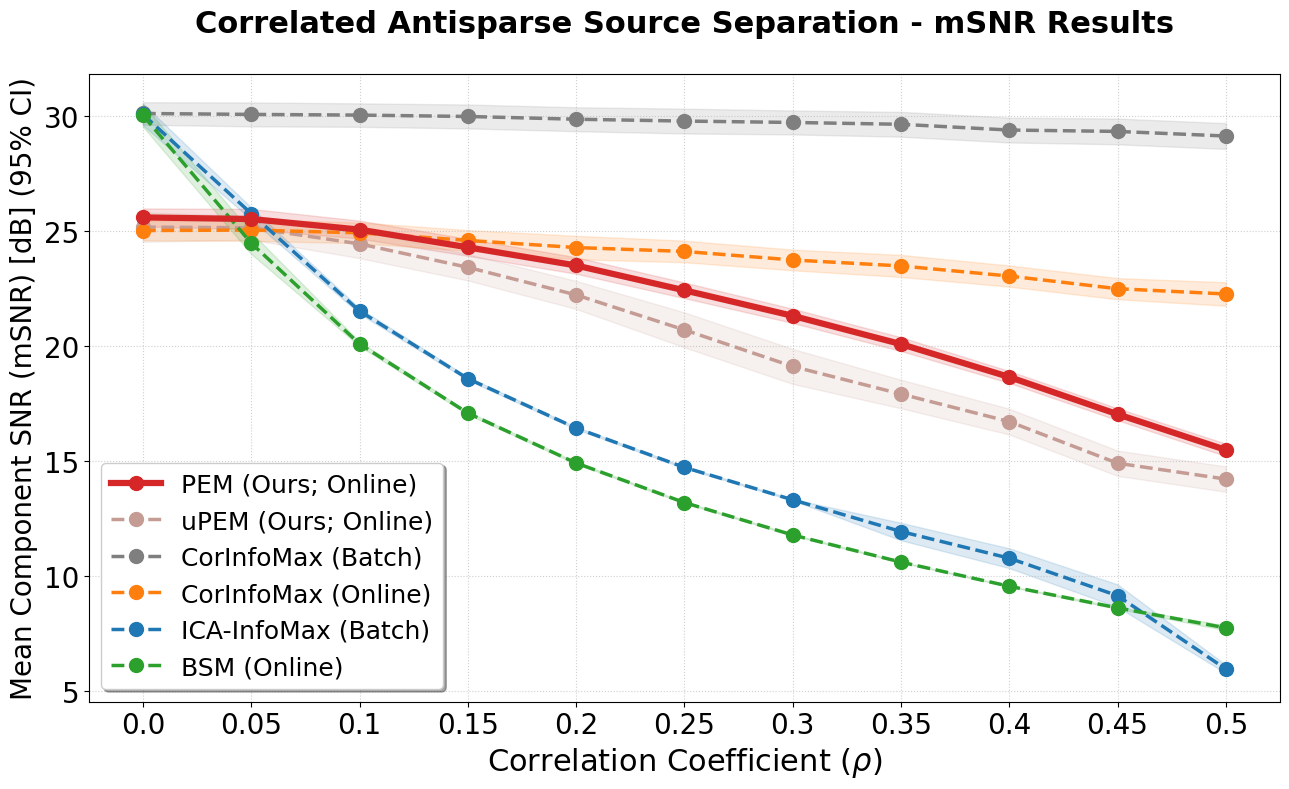

In [6]:
plot_title = "Correlated Antisparse Source Separation - mSNR Results"
bss_plot = plot_snr_performance(summary_df, title = plot_title)
# plt.savefig('Figures/Antisparse_Correlated_Comparison.pdf', format='pdf', bbox_inches = 'tight')
bss_plot.show()